In [1]:
import pandas  as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
sns.set_theme(style='whitegrid')

In [2]:
df=pd.read_csv('customers.csv')
df.head()

,CustomerID,Age,Annual_Income_k,Spending_Score
0,1,47,84,26
1,2,42,80,87
2,3,44,57,52
3,4,44,80,87
4,5,28,35,82


In [3]:
df.shape

(60, 4)

In [4]:
df.describe()

,CustomerID,Age,Annual_Income_k,Spending_Score
count,60.000000,60.000000,60.000000,60.000000
mean,30.500000,40.966667,55.716667,50.100000
std,17.464249,11.056046,24.752395,27.567913
min,1.000000,18.000000,22.000000,7.000000
25%,15.750000,34.750000,31.000000,22.000000
50%,30.500000,43.000000,54.000000,49.500000
75%,45.250000,49.000000,80.500000,79.250000
max,60.000000,61.000000,91.000000,91.000000


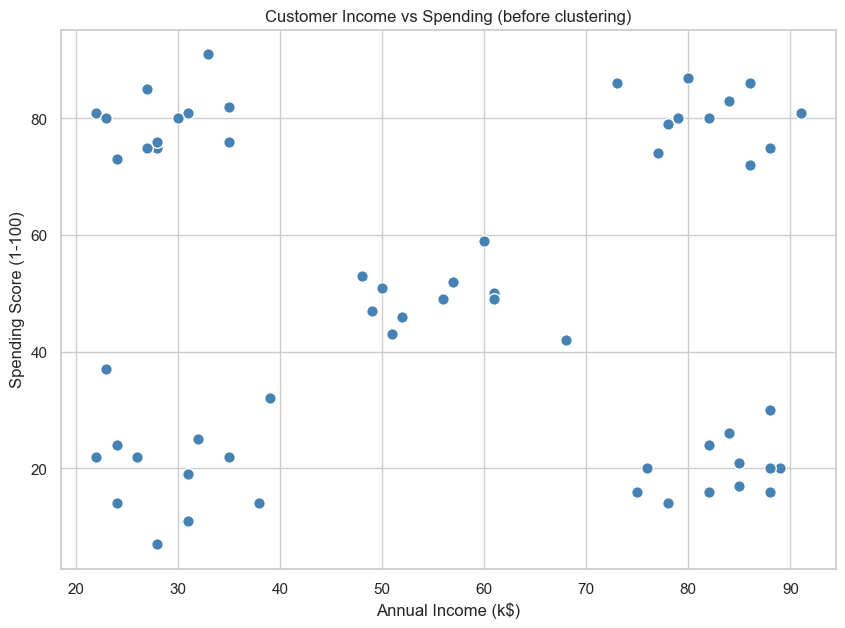

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter( df['Annual_Income_k'],df['Spending_Score'],s=70,c='steelblue',edgecolor='white')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Income vs Spending (before clustering)')
plt.show()

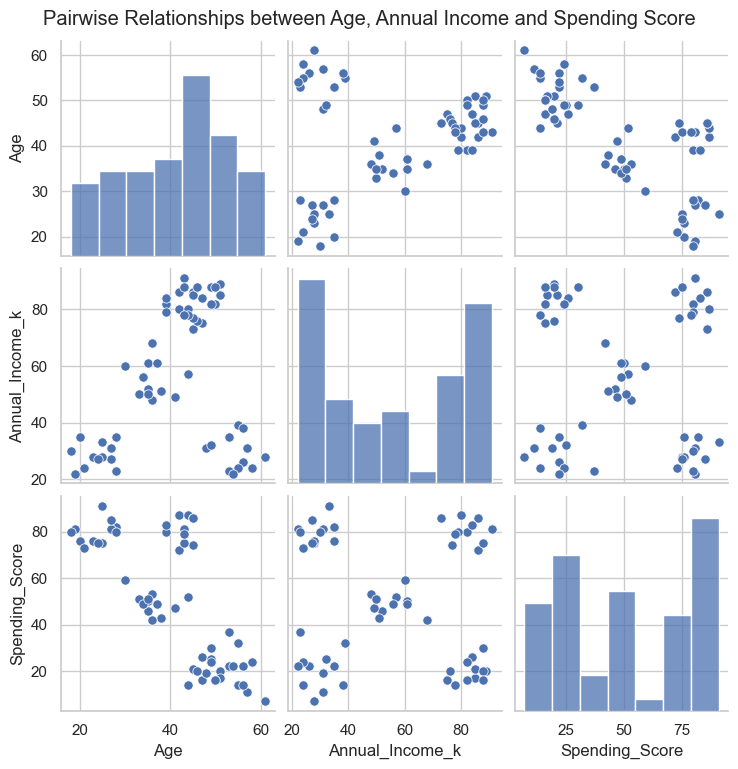

In [6]:
sns.pairplot(df[['Age', 'Annual_Income_k', 'Spending_Score']], diag_kind='hist', height=2.5, plot_kws=dict(s=45, edgecolor='white'))
plt.suptitle('Pairwise Relationships between Age, Annual Income and Spending Score', y=1.02)
plt.show()

In [7]:
features = ['Annual_Income_k', 'Spending_Score']
x= df[features].values
scaler=StandardScaler()
x_scaled= scaler.fit_transform(x)
print('Means after scaling:')
print(x_scaled.mean(axis=0))
print('Standard deviations after scaling:')
print(x_scaled.std(axis=0))

Means after scaling:
[-5.92118946e-17 -5.92118946e-17]
Standard deviations after scaling:
[1. 1.]


In [8]:
z= linkage(x_scaled, method='ward')
print('linkage matrix shape:',z.shape,"(=n_points-1 merges)")
print('first 5 merges:\n', np.round(z[:5],2))

linkage matrix shape: (59, 4) (=n_points-1 merges)
first 5 merges:
 [[1.0e+00 3.0e+00 0.0e+00 2.0e+00]
 [2.2e+01 4.7e+01 0.0e+00 2.0e+00]
 [2.3e+01 4.0e+01 4.0e-02 2.0e+00]
 [3.8e+01 3.9e+01 4.0e-02 2.0e+00]
 [9.0e+00 5.1e+01 4.0e-02 2.0e+00]]


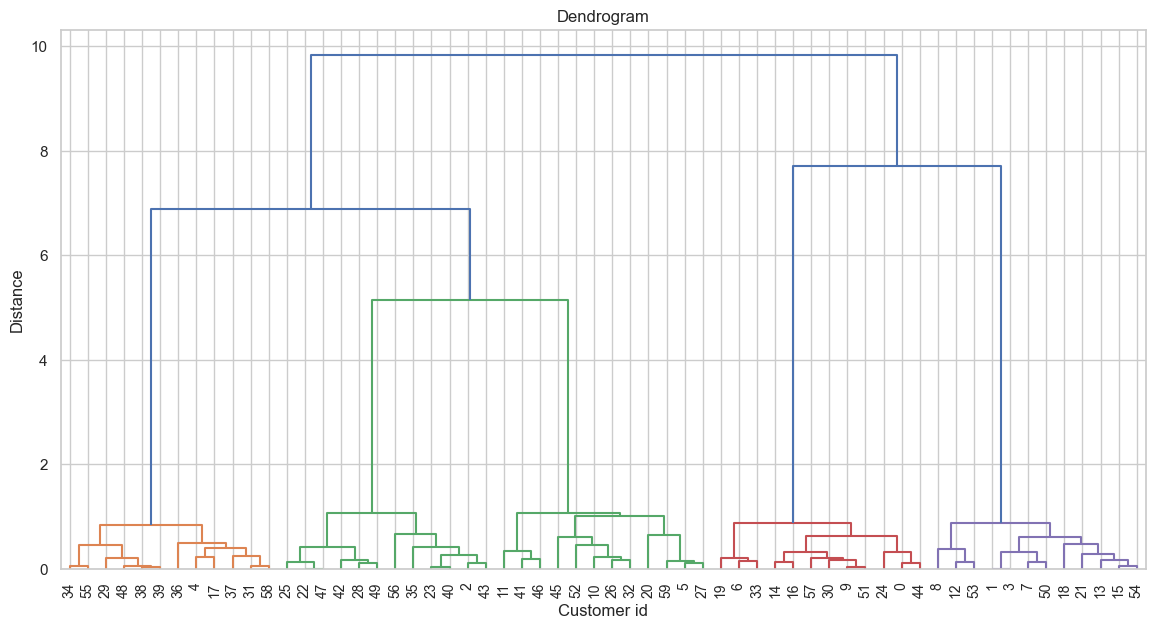

In [9]:
plt.figure(figsize=(14, 7))
dendrogram(z, leaf_rotation=90, leaf_font_size=10)
plt.title('Dendrogram')
plt.xlabel('Customer id')
plt.ylabel('Distance')
plt.tight_layout
plt.show()

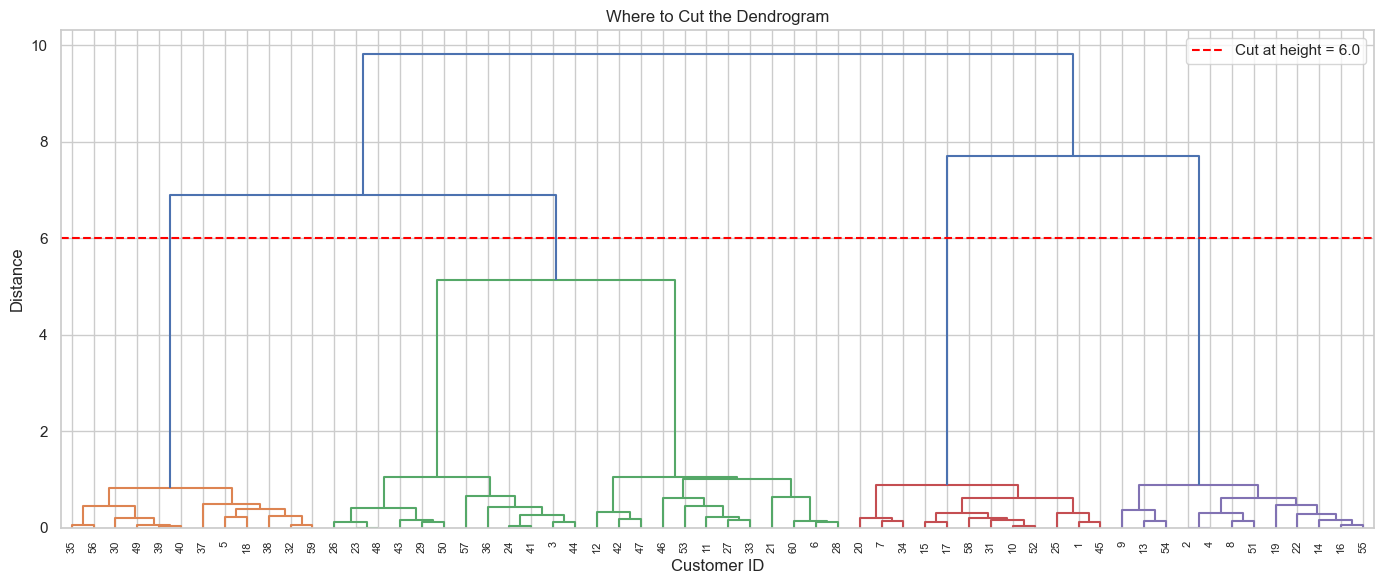

In [10]:
cut_height = 6.0
plt.figure(figsize=(14, 6))
dendrogram(
    z,
    labels=df['CustomerID'].astype(str).values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=cut_height
)
plt.axhline(
    y=cut_height,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Cut at height = {cut_height}'
)
plt.title('Where to Cut the Dendrogram')
plt.xlabel('Customer ID')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
for k in range (2,8):
    labels_k=fcluster(z, t=k , criterion='maxclust')
    score = silhouette_score(x_scaled ,labels_k)
    print(f"k={k}: silhouette = {score:3f}")

k=2: silhouette = 0.404940
k=3: silhouette = 0.518194
k=4: silhouette = 0.647991
k=5: silhouette = 0.739810
k=6: silhouette = 0.659083
k=7: silhouette = 0.594767


In [12]:
model = AgglomerativeClustering(n_clusters=5 , linkage='ward')
df['cluster']= model.fit_predict(x_scaled)
print('customers per cluster ')
print(df['cluster'].value_counts().sort_index())
df.head()

customers per cluster 
cluster
0    12
1    12
2    12
3    12
4    12
Name: count, dtype: int64


,CustomerID,Age,Annual_Income_k,Spending_Score,cluster
0,1,47,84,26,2
1,2,42,80,87,4
2,3,44,57,52,1
3,4,44,80,87,4
4,5,28,35,82,3
